# **NODIER David**

## Read ERA5 data and extract t2m

In [3]:
!pip install zarr cartopy gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 111.3 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import xarray as xr

In [5]:
obs_path = "gs://weatherbench2/datasets/era5/1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr"

ds = xr.open_zarr(
    obs_path,
    chunks=-1,
    storage_options=dict(token='anon'),
)

ds

<xarray.Dataset> Size: 1TB
Dimensions:                                           (time: 92040,
                                                       longitude: 240,
                                                       latitude: 121, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 736kB ...
  * longitude                                         (longitude) float64 2kB ...
  * latitude                                          (latitude) float64 968B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 11GB dask.array<chunksize=(92040, 240, 121), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 116kB dask.array<chunksize=(240, 121), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 139GB dask.array<chunksize=(92040, 13, 240, 121), meta=np.ndarray>

(time: 92040, longitude: 240, latitude: 121, level: 13) 13 pressure level, 92040 time steps, 240 longitude points and 121 latitude points

In [6]:
t2m_era5 = ds['2m_temperature'].sel(time=slice('2012','2022'))
t2m_era5

<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
dask.array<getitem, shape=(14612, 240, 121), dtype=float32, chunksize=(14612, 240, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

In [7]:
# Convert longitudes to the range [-180, 180] from [0, 360] (Greenwich meridian)
t2m_era5 = t2m_era5.assign_coords(longitude=((t2m_era5.longitude + 180) % 360) - 180)
# longitude + 180 --> [180, 540], then [180, 540]%340 --> [0, 360], and finally [0, 360]-180 --> [-180, 180]

# Sort the longitude coordinate to ensure it's in ascending order
t2m_era5 = t2m_era5.sortby(t2m_era5.longitude)

In [8]:
%%time
t2m_era5.load()

CPU times: user 6.33 s, sys: 2.09 s, total: 8.41 s
Wall time: 25.4 s


<xarray.DataArray '2m_temperature' (time: 14612, longitude: 240, latitude: 121)> Size: 2GB
array([[[247.5613 , 246.48785, 248.18385, ..., 247.94714, 247.75345,
         248.4725 ],
        [247.58649, 246.52144, 248.29346, ..., 248.09679, 247.78972,
         248.47717],
        [247.60933, 246.53728, 248.45322, ..., 248.25433, 247.81508,
         248.48003],
        ...,
        [247.49359, 246.41907, 248.02388, ..., 247.58807, 247.64714,
         248.4468 ],
        [247.51613, 246.43484, 248.04158, ..., 247.6902 , 247.6788 ,
         248.4558 ],
        [247.53864, 246.45473, 248.09517, ..., 247.81139, 247.71362,
         248.46484]],

       [[247.26103, 245.3764 , 247.82109, ..., 247.03183, 247.9408 ,
         248.56041],
        [247.28568, 245.39781, 247.92824, ..., 247.14998, 247.96423,
         248.56195],
        [247.30861, 245.40286, 248.08824, ..., 247.2754 , 247.97763,
         248.55998],
...
        [249.09322, 246.3282 , 244.75594, ..., 249.25995, 249.4646 ,
         249.60794],
        [249.10942, 246.33606, 244.77954, ..., 249.38194, 249.53622,
         249.62564],
        [249.1265 , 246.35115, 244.84526, ..., 249.47299, 249.61023,
         249.64354]],

       [[250.03273, 246.62439, 245.10814, ..., 247.99141, 248.51231,
         248.63118],
        [250.04376, 246.60828, 245.24507, ..., 248.09633, 248.58293,
         248.64381],
        [250.0533 , 246.57803, 245.41461, ..., 248.20886, 248.65361,
         248.65744],
        ...,
        [250.00562, 246.77924, 244.92578, ..., 247.71996, 248.29391,
         248.58603],
        [250.01385, 246.71208, 244.94186, ..., 247.7925 , 248.36647,
         248.60127],
        [250.02264, 246.65622, 244.99756, ..., 247.88689, 248.44096,
         248.61685]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 117kB 2012-01-01 ... 2021-12-31T18:00:00
  * longitude  (longitude) float64 2kB -180.0 -178.5 -177.0 ... 177.0 178.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K

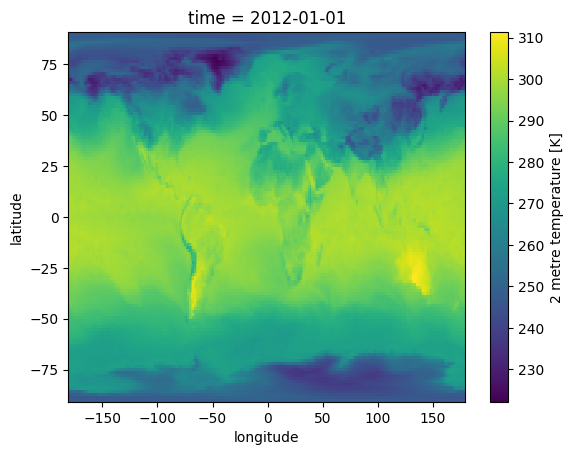

In [9]:
t2m_era5.isel(time=0).plot(x='longitude',y='latitude')

# Coarsening the data

In [ ]:
from scipy.ndimage import gaussian_filter

# Define sigma (standard deviation of the Gaussian kernel)
sigma = 3.0

# Apply Gaussian filter across spatial dimensions only (latitude, longitude)
t2m_smooth_values = gaussian_filter(t2m_era5.values, sigma=(0, sigma, sigma))

# Create a new DataArray with the smoothed data
t2m_smooth = xr.DataArray(
    t2m_smooth_values,
    coords=t2m_era5.coords,
    dims=t2m_era5.dims,
    attrs=t2m_era5.attrs
)

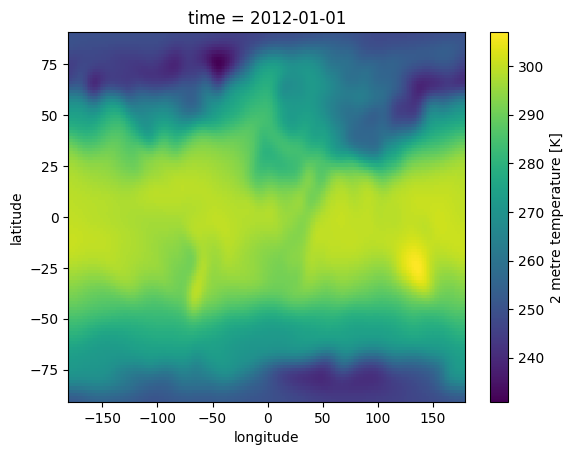

In [15]:
t2m_smooth.isel(time=0).plot(x='longitude', y='latitude')

an exemple of an error map after coarsening the data

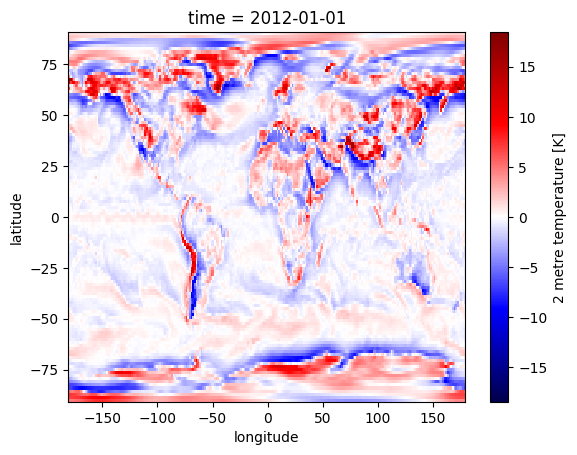

In [16]:
(t2m_smooth-t2m_era5).isel(time=0).plot(x='longitude',y='latitude', cmap='seismic')

# **Python Implementation**

In this implementation, I train an U-Net model. The model receives the smoothed temperature field `t2m_smooth` as input and learns to predict a reconstructed temperature field `t2m_prediction`.

The goal is that the prediction becomes as close as possible to the original ERA5 field `t2m_era5`.

## 1 - Architecture

For this project, I use the IPSL-AID GitHub repository in order to use the Song U-Net model.

In [1]:
# Clone the IPSL-AID GitHub repository in order to access the SongUNet implementation
!git clone https://github.com/kardaneh/IPSL-AID.git
%cd IPSL-AID
!pip install -e .

Cloning into 'IPSL-AID'...
remote: Enumerating objects: 961, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 961 (delta 44), reused 20 (delta 18), pack-reused 891 (from 2)
Receiving objects: 100% (961/961), 11.13 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (493/493), done.
/content/IPSL-AID
Obtaining file:///content/IPSL-AID
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 13.7 MB/s eta

**Explanation:** We will import the Song U-Net architecture defined in the `networks.py` file and modify it.

In [18]:
import copy
import time
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.nn.functional import silu
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Import the SongUNet architecture
from IPSL_AID.networks import (
    SongUNet,
    Linear,
    Conv2d,
    GroupNorm,
    UNetBlock,
)

**Explanation :**

I use the Song U-Net architecture provided in the IPSL-AID GitHub repository. In the original IPSL-AID framework, this architecture is used as the neural denoising network inside a diffusion model, together with noise/timestep conditioning and diffusion preconditioning.

In this notebook, I adapt SongUNet to a deterministic supervised setting. The goal is not to perform iterative diffusion sampling, but to directly learn a mapping from the smoothed temperature field to the original ERA5 temperature field:

$$
t2m_{era5} = F(t2m_{smooth})
$$

To do this, I keep the original SongUNet encoder-decoder architecture unchanged, but I disable the noise/timestep embedding. Since the U-Net blocks still expect an embedding vector, I replace the original noise embedding with a zero embedding of the same dimension. This allows us to reuse the IPSL-AID SongUNet architecture without diffusion preconditioning.

In [19]:
class DeterministicSongUNet(SongUNet):
    """
    SongUNet without preconditioning.

    This class reuses the original IPSL-AID SongUNet architecture, but disables
    the noise embedding and replaces it with a zero embedding in the forward pass.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Store the input dimension expected by map_layer0.
        # In SongUNet, map_layer0 maps noise_channels -> emb_channels.
        self.noise_channels = self.map_layer0.in_features

    def forward(self, x, class_labels=None, augment_labels=None):
        # Start from a zero embedding with the same shape as the original
        # noise embedding would have produced.
        emb = torch.zeros(
            [x.shape[0], self.noise_channels],
            device=x.device,
            dtype=x.dtype,
        )


        if self.map_label is not None:
            if class_labels is None:
                class_labels = torch.zeros(
                    [x.shape[0], self.map_label.in_features],
                    device=x.device,
                    dtype=x.dtype,
                )

            tmp = class_labels

            if self.training and self.label_dropout:
                tmp = tmp * (
                    torch.rand([x.shape[0], 1], device=x.device) >= self.label_dropout
                ).to(tmp.dtype)

            emb = emb + self.map_label(tmp * np.sqrt(self.map_label.in_features))


        if self.map_augment is not None and augment_labels is not None:
            emb = emb + self.map_augment(augment_labels)

        # Same mapping layers as original SongUNet.
        emb = silu(self.map_layer0(emb))
        emb = silu(self.map_layer1(emb))

        # Encoder: same as original SongUNet.
        skips = []
        aux = x

        for name, block in self.enc.items():
            if "aux_down" in name:
                aux = block(aux)

            elif "aux_skip" in name:
                x = skips[-1] = x + block(aux)

            elif "aux_residual" in name:
                x = skips[-1] = aux = (x + block(aux)) / np.sqrt(2)

            else:
                x = block(x, emb) if isinstance(block, UNetBlock) else block(x)
                skips.append(x)

        # Decoder: same as original SongUNet.
        aux = None
        tmp = None

        for name, block in self.dec.items():
            if "aux_up" in name:
                aux = block(aux)

            elif "aux_norm" in name:
                tmp = block(x)

            elif "aux_conv" in name:
                tmp = block(silu(tmp))
                aux = tmp if aux is None else tmp + aux

            else:
                if x.shape[1] != block.in_channels:
                    x = torch.cat([x, skips.pop()], dim=1)

                x = block(x, emb)

        return aux

# 2 - Data Preparation, Normalization and DataLoader


In this section, I prepare the temperature fields so that they can be used by PyTorch. I first reorder the spatial dimensions, crop the latitude dimension from 121 to 120 points to make the grid compatible with U-Net downsampling and upsampling, then split the data into training, validation and test sets. After that, I define a custom PyTorch Dataset that normalizes the data using training statistics only and returns tensors in the format expected by convolutional neural networks.

### 2.1 - Reordering and Cropping the Data for PyTorch

In [20]:
# Original xarray order: (time, longitude, latitude)
# New order: (time, latitude, longitude)
t2m_era5_model = t2m_era5.transpose("time", "latitude", "longitude")
t2m_smooth_model = t2m_smooth.transpose("time", "latitude", "longitude")

# Crop: 121 latitude points -> 120 latitude points
# This makes the spatial size easier for U-Net downsampling/upsampling.
t2m_era5_model = t2m_era5_model.isel(latitude=slice(0, 120))
t2m_smooth_model = t2m_smooth_model.isel(latitude=slice(0, 120))

print("ERA5 shape:", t2m_era5_model.shape)
print("Smooth shape:", t2m_smooth_model.shape)

ERA5 shape: (14612, 120, 240)
Smooth shape: (14612, 120, 240)


**Explanation**: The original xarray data are organized as `(time, longitude, latitude)`. Since Song U-Net is a convolutional U-Net architecture implemented in PyTorch, each sample must later be represented as `[channels, height, width]`. Therefore, I transpose the data to `(time, latitude, longitude)`, so that latitude corresponds to the height dimension and longitude to the width dimension.

I also crop the latitude dimension from 121 to 120 points. This is useful because the U-Net performs several downsampling and upsampling operations by a factor of 2. With a grid of `120 x 240`, the spatial dimensions are easier to divide and reconstruct during the U-Net forward pass.

### 2.2 - Train / Validation / Test Split

I use the first 8 years for training, the 9th year for validation, and the 10th year for testing.  

Therefore, I use:

- 2012-2019 for training
- 2020 for validation
- 2021 for testing

In [21]:
# Training period: first 8 years
# train_input contains the smoothed temperature fields obtained after Gaussian smoothing.
# train_target contains the original ERA5 temperature fields, used as labels.
train_input = t2m_smooth_model.sel(time=slice("2012", "2019"))
train_target = t2m_era5_model.sel(time=slice("2012", "2019"))


# Validation period: 9th year
# val_input is the smoothed validation data.
# val_target is the corresponding original ERA5 data, used as validation labels.
val_input = t2m_smooth_model.sel(time=slice("2020", "2020"))
val_target = t2m_era5_model.sel(time=slice("2020", "2020"))


# Test period: 10th year
# test_input is the smoothed test data.
# test_target is the corresponding original ERA5 data, used as test labels.
test_input = t2m_smooth_model.sel(time=slice("2021", "2021"))
test_target = t2m_era5_model.sel(time=slice("2021", "2021"))

print("Train input:", train_input.shape)
print("Train target:", train_target.shape)
print("Validation input:", val_input.shape)
print("Validation target:", val_target.shape)
print("Test input:", test_input.shape)
print("Test target:", test_target.shape)

Train input: (11688, 120, 240)
Train target: (11688, 120, 240)
Validation input: (1464, 120, 240)
Validation target: (1464, 120, 240)
Test input: (1460, 120, 240)
Test target: (1460, 120, 240)


**Explanation:**

I split the dataset into three temporal subsets: training, validation and test. For each subset, I keep two versions of the same temperature field:

- the smoothed version, obtained with Gaussian smoothing, which is used as the model input
- the original ERA5 version, which is used as the target label

The training set covers the years 2012-2019 and contains 11688 samples.  
The validation set uses the year 2020 and contains 1464 samples.  
The test set uses the year 2021 and contains 1460 samples.


### 2.3 - Dataset Class and Standard Normalization

I define a custom PyTorch Dataset for the supervised inverse problem.

In [22]:
class T2MDownscalingDataset(Dataset):
    """
    Dataset for the inverse problem:
        t2m_era5 = F(t2m_smooth)

    Input:
        smoothed 2m temperature field

    Target:
        original ERA5 2m temperature field

    Each sample corresponds to one full spatial field at one time step.
    """

    def __init__(self, input_da, target_da, mean, std):
        # Store input and target xarray DataArrays
        self.input_da = input_da
        self.target_da = target_da
        # Store normalization statistics computed on the training set only
        self.mean = mean
        self.std = std

    def __len__(self):
        return self.input_da.sizes["time"]

    def __getitem__(self, idx):
        # Extract one time step
        x = self.input_da.isel(time=idx).values.astype("float32")
        y = self.target_da.isel(time=idx).values.astype("float32")

        # Normalize using training statistics only
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        # Add channel dimension: [H, W] -> [1, H, W]
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y

**Explanation:**

Each sample corresponds to one full temperature map at one time step. The input is the smoothed temperature field, and the target is the original ERA5 temperature field.

The data are normalized using a standard z-score normalization:

`x_norm = (x - mean_train) / std_train`

The mean and standard deviation are computed only on the training set. The same statistics are then applied to the training, validation and test data.

Finally, I add a channel dimension because PyTorch convolutional models expect tensors with shape `[channels, height, width]` for each sample. Since I only use one variable, 2m temperature, the number of channels is 1.

### 2.4 - DataLoaders

Now, I create the PyTorch Dataset and DataLoader objects.

In [23]:
# Compute normalization statistics using the training set only.
train_mean = float(np.mean(train_target.values))
train_std = float(np.std(train_target.values))

# Create PyTorch Dataset objects for each split.
# The same training mean and standard deviation are used for all splits.
train_dataset = T2MDownscalingDataset(train_input, train_target, train_mean, train_std)
val_dataset = T2MDownscalingDataset(val_input, val_target, train_mean, train_std)
test_dataset = T2MDownscalingDataset(test_input, test_target, train_mean, train_std)

batch_size = 4

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([4, 1, 120, 240])
torch.Size([4, 1, 120, 240])


**Explanation :**

If a feature is normalized during training, the same normalization must be applied during inference. Therefore, the val inputs and the test inputs are normalized using the training mean and standard deviation before being passed to the model. The model outputs are then denormalized back to Kelvin for evaluation and visualization.

I use `batch_size = 4` because each sample is a full spatial map of size `120 x 240`, and the U-Net model can be memory-consuming on a free GPU. A small batch size reduces GPU memory usage and makes the training more stable in a limited computing environment.

# 3 - Model Training

In this section, I train the adapted Song U-Net model. The model receives the smoothed temperature field `t2m_smooth` as input and learns to reconstruct the original ERA5 temperature field `t2m_era5`. I first instantiate the deterministic Song U-Net, then define the training parameters, implement the training loop, and finally launch the training.

### 3.1 - Instantiate the Model

In [24]:
# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Instantiate the deterministic Song U-Net model
model = DeterministicSongUNet(
    img_resolution=(120, 240),
    in_channels=1,  # We use only one input variable: smoothed 2m temperature
    out_channels=1, # We predict only one output variable: original ERA5 2m temperature
    label_dim=0,
    augment_dim=0,
    model_channels=32,
    channel_mult=[1, 2, 2, 2],
    channel_mult_emb=4,
    num_blocks=2,
    attn_resolutions=[30, 15],
    dropout=0.10,
    label_dropout=0,
    embedding_type="positional",
    channel_mult_noise=1,
    encoder_type="standard",
    decoder_type="standard",
    resample_filter=[1, 1],
)

# Move the model to GPU or CPU
model = model.to(device)

# Count the number of trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params:,}")

Device: cuda
Number of trainable parameters: 2,523,937


**Explanation:**

The model input has shape `[batch_size, 1, 120, 240]`. The value `in_channels=1` is used because the input contains only one variable: the smoothed 2m temperature field. The value `out_channels=1` is used because the model predicts one variable: the original ERA5 2m temperature field.

I use `img_resolution=(120, 240)` because the latitude dimension was cropped from 121 to 120 points. This gives a spatial grid of 120 latitude points and 240 longitude points.

The original IPSL-AID SongUNet uses `model_channels=128` and `num_blocks=4`. Here, I use `model_channels=32` and `num_blocks=2` to make the model lighter and easier to train on a limited GPU environment.

I use `attn_resolutions=[30, 15]` because the U-Net resolution levels for an input of `120 x 240` are `120x240`, `60x120`, `30x60`, and `15x30`. The original default value `attn_resolutions=[16]` would not be triggered exactly with our input resolution, because none of these levels has a minimum spatial size equal to 16.

Therefore, I apply self-attention at the two deepest levels, `30x60` and `15x30`. I use two attention levels instead of only one because our model is reduced compared to the original IPSL-AID SongUNet: I use fewer channels and fewer residual blocks. Adding attention at the two deepest levels helps preserve some large-scale spatial modeling capacity, while keeping the computational cost reasonable because these feature maps are already downsampled.

### 3.2 - Training parameters

We define the loss function, the optimizer and the learning rate scheduler.

In [25]:
# Mean Squared Error loss
criterion = nn.MSELoss()

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

# Learning rate scheduler
scheduler = lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.5,
)

**Explanation:**

I use `MSELoss` because the task is a regression problem: the model predicts continuous temperature values. MSE penalizes large reconstruction errors and is commonly used for image-to-image reconstruction tasks.

I use the `AdamW` optimizer with a learning rate of `1e-4`. This value was chosen as a reasonable default learning rate for stable training. Since the model is trained for only 10 epochs `1e-4` is a conservative choice: it allows the model to learn without making the optimization unstable.

The `weight_decay=1e-4` term is also used as a standard default regularization value. It helps reduce overfitting by discouraging excessively large weights.

The scheduler reduces the learning rate during training. Since I train for only 5 epochs, I set `step_size=3`: the model trains with the initial learning rate during the first 2 epochs, then the learning rate is divided by 2 for the last 3 epochs using `gamma=0.5`. This allows the model to learn with larger updates at the beginning, and then refine its weights with smaller updates near the end of training.

### 3.3 - Training function

The training loop is adapted from a standard PyTorch U-Net training notebook :

https://colab.research.google.com/github/usuyama/pytorch-unet/blob/master/pytorch_unet_resnet18_colab.ipynb#scrollTo=4lcY1ziTLblo

The goal of this function is to train the model, evaluate it on the validation set after each epoch, save the best checkpoint, and store the training and validation losses.

In [26]:
from tqdm.auto import tqdm
import torch.nn.functional as F

# Path where the best model weights will be saved
checkpoint_path = "best_songunet_t2m.pth"


def calc_loss(pred, target, metrics):
    """
    Compute MSE / L2 loss and update training metrics.
    pred and target are normalized tensors.
    """

    # Compute MSE between prediction and target
    loss = F.mse_loss(pred, target)

    # Multiply by batch size to accumulate the total loss over the epoch
    batch_size = target.size(0)
    metrics["mse_loss"] += loss.detach().cpu().item() * batch_size

    return loss


def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for key in metrics.keys():
        outputs.append(f"{key}: {metrics[key] / epoch_samples:.6f}")
    print(f"{phase}: {', '.join(outputs)}")



def train_model(model, optimizer, scheduler, dataloaders, device, num_epochs=5):
    best_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        since = time.time()

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            # Progress bar for monitoring the current epoch
            progress_bar = tqdm(
                dataloaders[phase],
                desc=f"{phase} epoch {epoch + 1}/{num_epochs}",
                leave=True,
            )

            for batch_idx, (inputs, targets) in enumerate(progress_bar):
                inputs = inputs.to(device)
                targets = targets.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # Enable gradients only during the training phase
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = calc_loss(outputs, targets, metrics) # MSE loss

                    # backward + optimize only if in training phase
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                # Update number of processed samples
                epoch_samples += inputs.size(0)

                # Current average loss
                running_loss = metrics["mse_loss"] / epoch_samples

                # Update progress bar information
                progress_bar.set_postfix(
                    {
                        "batch": f"{batch_idx + 1}/{len(dataloaders[phase])}",
                        "images": f"{epoch_samples}/{len(dataloaders[phase].dataset)}",
                        "mse": f"{running_loss:.6f}",
                    }
                )

            # Print average metrics for the full phase
            print_metrics(metrics, epoch_samples, phase)

            # Compute average epoch loss
            epoch_loss = metrics["mse_loss"] / epoch_samples

            if phase == "train":

                # Store training loss
                history["train_loss"].append(epoch_loss)

                # Update the learning rate after each training epoch
                if scheduler is not None:
                    scheduler.step()
                    current_lr = optimizer.param_groups[0]["lr"]
                    print(f"Learning rate: {current_lr:.2e}")

            else:
                # Store validation loss
                history["val_loss"].append(epoch_loss)

                # Save the model if validation loss improves
                if epoch_loss < best_loss:
                    print(f"Saving best model to {checkpoint_path}")
                    best_loss = epoch_loss
                    torch.save(model.state_dict(), checkpoint_path)

        time_elapsed = time.time() - since
        print(f"Epoch time: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

    print(f"\nBest validation loss: {best_loss:.6f}")
    print(f"Best checkpoint saved at: {checkpoint_path}")

    return model, history

**Explanation:**

The function `train_model` performs the full training procedure. For each epoch, it runs two phases: a training phase and a validation phase.

During the training phase, the model is set to `model.train()`. Gradients are computed, the loss is backpropagated, and the optimizer updates the model weights.

During the validation phase, the model is set to `model.eval()`.

The dictionary `history` stores the training and validation losses at each epoch. This is useful to plot learning curves and check whether the model is learning correctly or overfitting.

The best model is saved using the validation loss. If the validation loss improves, the model weights are saved in `best_songunet_t2m.pth`.

### 3.4 - Run the Training

We now launch the training for 5 epochs. The dictionary `dataloaders` gives the training function access to both the training and validation DataLoaders.

In [27]:
# Group the train and validation DataLoaders in a dictionary
dataloaders = {
    "train": train_loader,
    "val": val_loader,
}

# Number of training epochs.
num_epochs = 10

# Launch the training process
model, history = train_model(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    dataloaders=dataloaders,
    device=device,
    num_epochs=num_epochs,
)


Epoch 1/10
----------


train epoch 1/10:   0%|          | 0/2922 [00:00<?, ?it/s]

train: mse_loss: 0.011246
Learning rate: 1.00e-04


val epoch 1/10:   0%|          | 0/366 [00:00<?, ?it/s]

val: mse_loss: 0.001322
Saving best model to best_songunet_t2m.pth
Epoch time: 8m 44s

Epoch 2/10
----------


...

val: mse_loss: 0.000702
Saving best model to best_songunet_t2m.pth
Epoch time: 8m 44s

Epoch 10/10
----------


train epoch 10/10:   0%|          | 0/2922 [00:00<?, ?it/s]

train: mse_loss: 0.000771
Learning rate: 5.00e-05


val epoch 10/10:   0%|          | 0/366 [00:00<?, ?it/s]

val: mse_loss: 0.000702
Saving best model to best_songunet_t2m.pth
Epoch time: 8m 45s

Best validation loss: 0.000702
Best checkpoint saved at: best_songunet_t2m.pth


**Training results explanation:**

The model was trained for 10 epochs. During training, the MSE loss decreased strongly, showing that the model learned the mapping from the smoothed temperature field to the original ERA5 temperature field.

The validation loss also decreased from `0.001322` at epoch 1 to approximately `0.000702` at the end of training. The best model checkpoint was saved as `best_songunet_t2m.pth` when the validation loss improved.

The learning rate scheduler reduced the learning rate after epoch 7, from `1e-4` to `5e-5`. This allowed the model to continue training with smaller optimization steps during the last epochs.

The losses are computed on normalized temperature fields, not directly in Kelvin.

### 3.5 - Loss curve

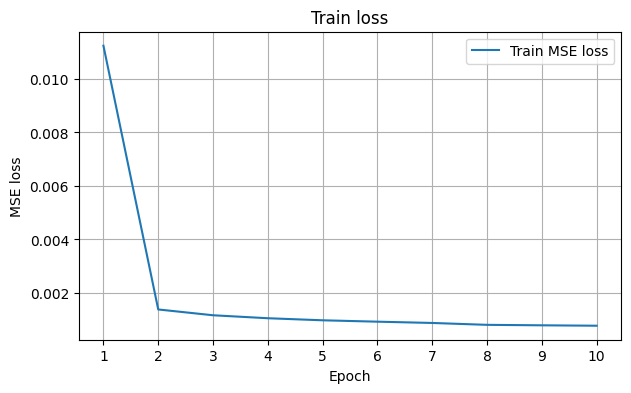

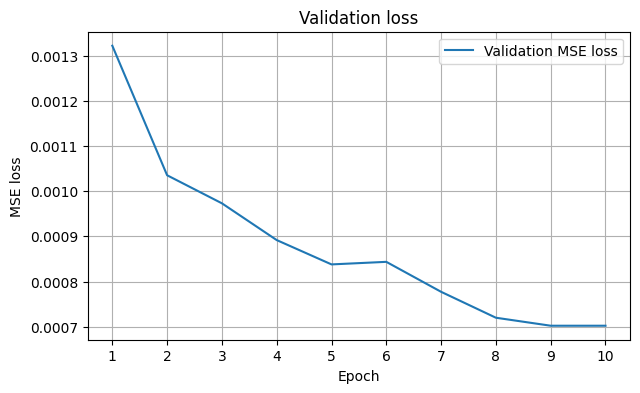

In [28]:
# Plot the evolution of the validation losses.
# Validation losses obtained during training


epochs = range(1, len(history["train_loss"]) + 1)

# Train MSE Loss
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Train MSE loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Train loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["val_loss"], label="Validation MSE loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Validation loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

**Loss curve interpretation:**

The train loss and the validation loss curve shows that the model trains correctly overall. The loss generally decreases during training, which indicates that the model progressively learns the inverse mapping. The validation loss decreases also and reaches a low value at the end of training, suggesting that the model converge.

### 3.6 - Save the Best Model Checkpoint Locally

In [29]:
# Import the Colab files module to download files from the notebook environment
from google.colab import files

# Download the best model checkpoint saved during training
files.download("best_songunet_t2m.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4 - Evaluation and Visualization

In this section, I evaluate the adapted Song U-Net model on the 2021 test set and I compare the model prediction with the original ERA5 field and with the smoothed baseline.

The evaluation includes:

- quantitative metrics: RMSE, MAE and $R^2$;
- a spatial MAE map;
- an upper-tail quantile analysis;
- distribution-level diagnostics using IPSL-AID plotting functions;
- qualitative surface visualizations.
- hexbin validation

### 4.1 - Import IPSL-AID Diagnostic Functions

In this evaluation section, I reuse some diagnostic functions from the IPSL-AID GitHub repository. This allows us to evaluate the adapted Song U-Net model with tools that are close to those used in the original IPSL-AID workflow.

In [42]:
from IPSL_AID.diagnostics import (
    plot_qq_quantiles,
    plot_surface,
    plot_MAE_map,
    plot_power_spectra,
    plot_validation_hexbin,
)

from IPython.display import Image, display
import pandas as pd

### 4.2 - Evaluation Functions

Before running the evaluation, I define two functions. The first one converts normalized tensors back to Kelvin. The second one computes RMSE, MAE and $R^2$.

In [31]:
def denormalize(x, mean, std):
    """
    Convert normalized data back to Kelvin.
    """
    return x * std + mean


def compute_metrics(pred, target):
    """
    Compute global RMSE, MAE and R² between prediction and target.

    pred and target are numpy arrays in Kelvin.
    Expected shape: [N, C, H, W]
    """

    error = pred - target

    # Global RMSE over all test samples and grid points
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)

    # Global MAE over all test samples and grid points
    mae = np.mean(np.abs(error))

    # Global R² over all test samples and grid points
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - np.mean(target)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }

### 4.3 - Test Inference

I load the best checkpoint and run inference on the 2021 test set. Since the test DataLoader uses `shuffle=False`, the predictions remain in the same temporal order as `test_input` and `test_target`.

In [ ]:
"""
If the model has already been trained and the checkpoint file `best_songunet_t2m.pth` has been saved locally, it can be uploaded here.

This avoids retraining the model every time the Google Colab session restarts.

This cell is optional: it should only be executed if the checkpoint is not already available in the current Colab environment.
"""

from google.colab import files
import os
# Upload the checkpoint file from your local computer
uploaded = files.upload()

# Get the uploaded filename
checkpoint_path = list(uploaded.keys())[0]

print("Uploaded checkpoint:", checkpoint_path)
print("File exists:", os.path.exists(checkpoint_path))

Saving best_songunet_t2m.pth to best_songunet_t2m.pth
Uploaded checkpoint: best_songunet_t2m.pth
File exists: True


In [32]:
# Load the best checkpoint before test inference
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

t2m_era5_prediction = []


with torch.no_grad():
    for inputs, targets in test_loader:

        inputs = inputs.to(device)

        # predict ERA5 temperature from smoothed temperature
        outputs = model(inputs)

        # Move to CPU and convert to numpy
        outputs_np = outputs.cpu().numpy()


        # Denormalize back to Kelvin
        outputs_np = denormalize(outputs_np, train_mean, train_std)

        # Store predictions
        t2m_era5_prediction.append(outputs_np)

# Concatenate all prediction batches along the time dimension
t2m_era5_prediction = np.concatenate(t2m_era5_prediction, axis=0)

### 4.4 - Prepare Test Arrays for Evaluation

The model prediction is a NumPy array with shape `[time, channel, latitude, longitude]`. The original `test_input` and `test_target` are xarray DataArrays with shape `[time, latitude, longitude]`. Therefore, I add a channel dimension to make the baseline and target compatible with the prediction shape.

In [33]:
# Original t2m_era5 on the test period
t2m_era5_original = test_target.values[:, None, :, :]

# Smoothed t2m_era5 input on the test period, used as the baseline
t2m_era5_smooth_version = test_input.values[:, None, :, :]

print("Original t2m_era5 shape:", t2m_era5_original.shape)
print("Smooth baseline shape:", t2m_era5_smooth_version.shape)
print("Prediction shape:", t2m_era5_prediction.shape)

Original t2m_era5 shape: (1460, 1, 120, 240)
Smooth baseline shape: (1460, 1, 120, 240)
Prediction shape: (1460, 1, 120, 240)


### 4.5 - Quantitative Metrics: RMSE, MAE and $R^2$

I compare the smoothed baseline and the model prediction against the same ERA5 reference. The objective is to verify whether the adapted Song U-Net prediction is closer to ERA5 than the smoothed input.

In [34]:
# Compute metrics for the baseline and the model prediction
baseline_metrics = compute_metrics(t2m_era5_smooth_version, t2m_era5_original)
prediction_metrics = compute_metrics(t2m_era5_prediction, t2m_era5_original)

# Create a comparison table between the baseline and the model prediction
results_table = pd.DataFrame({
    "Baseline (t2m_smooth)": baseline_metrics,
    "Prediction (t2m_prediction)": prediction_metrics,
})

results_table = results_table.round(3)

display(results_table)

,Baseline (t2m_smooth),Prediction (t2m_prediction)
RMSE,2.617,0.572
MAE,1.657,0.390
R2,0.985,0.999


#### **Interpretation:**

By computing RMSE, MAE and $R^2$, we can see that the model performs better than the Gaussian-smoothed baseline `t2m_smooth`. The model prediction `t2m_prediction` is closer to the ground truth `t2m_era5_original`.

For example, the RMSE decreases from 2.617 K for the baseline to 0.572 K for the model prediction. The MAE also decreases from 1.657 K to 0.390 K. This means that the adapted Song U-Net successfully reduces the error introduced by the Gaussian smoothing and reconstructs a temperature field closer to ERA5.

The R² score is already very high for the baseline, 0.985, because the smoothed field preserves most of the large-scale temperature structure. However, the model still improves the R² score to 0.999.

Overall, these metrics confirm that the model predicts temperature fields closer to `t2m_era5_original` than the smoothed baseline.

### 4.6 - Extreme Quantile Analysis

In addition to RMSE, MAE and $R^2$, I evaluate upper-tail quantiles of the temperature distribution. This follows the same idea as the IPSL-AID article, where quantiles are used to analyze extreme values.

[QQ Quantiles] 2m Temperature [K]
  q=0.900 | Truth=300.0551 | Pred=300.1512 | Coarse=299.7709 
  q=0.950 | Truth=301.1119 | Pred=301.1404 | Coarse=300.6667 
  q=0.975 | Truth=302.3896 | Pred=302.4425 | Coarse=301.5940 
  q=0.990 | Truth=306.1585 | Pred=306.2119 | Coarse=304.1450 
  q=0.995 | Truth=308.9095 | Pred=308.9593 | Coarse=306.4271 


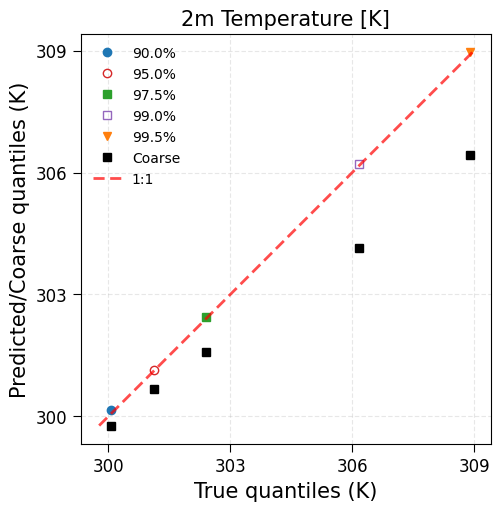

In [35]:
# It compares upper-tail quantiles of prediction and baseline against ERA5 truth.
qq_plot_path = plot_qq_quantiles(
    predictions=t2m_era5_prediction,
    targets=t2m_era5_original,
    coarse_inputs=t2m_era5_smooth_version,
    variable_names=["T2M"],
    units=["K"],
    quantiles=[0.90, 0.95, 0.975, 0.99, 0.995],
    filename="songunet_t2m_qq_quantiles.png",
    save_dir="./results",
    figsize_multiplier=5,
)

display(Image(filename=qq_plot_path))

#### **Interpretation:**

The QQ quantile plot compares the upper-tail quantiles of the ground truth `t2m_era5_original`, the model prediction and the smoothed baseline.

In this plot, the colored markers correspond to the quantiles of the model prediction, while the black squares correspond to the smoothed baseline. The red dashed line represents the ideal 1:1 line, where the predicted or baseline quantile is exactly equal to the true ERA5 quantile.

The model prediction quantiles are very close to the truth quantiles. For example, at q=0.95, the truth value is 301.11 K and the prediction is 301.14 K. At q=0.995, the truth value is 308.91 K and the prediction is 308.96 K.

The smoothed baseline is generally farther from the truth, especially for the highest quantiles. For instance, at q=0.995, the baseline gives 306.42 K while the truth is 308.90 K. This shows that Gaussian smoothing tends to underestimate some high-temperature extremes.

Overall, the quantile analysis shows that the adapted Song U-Net improves the reconstruction of high-temperature extremes. The predicted quantiles are closer to the ERA5 truth than the smoothed baseline, which means that the model better preserves the upper tail of the temperature distribution.


### 4.7 - Spectral Analysis with Power Spectral Density

Power Spectral Density is used to evaluate whether the model restores spatial variability across scales. The smoothed baseline is expected to lose energy at high spatial frequencies because Gaussian smoothing removes small-scale details.

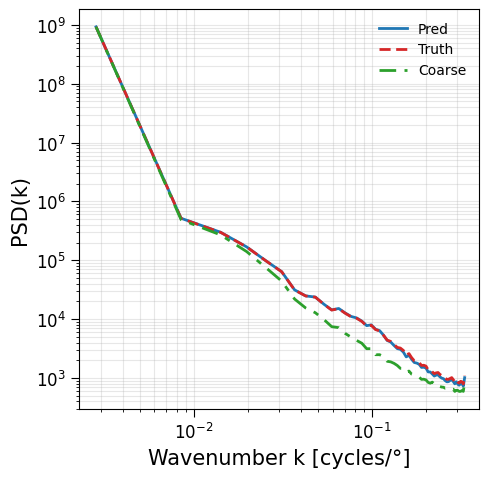

In [36]:
# Compute grid spacing in degrees
dlat = float(abs(test_target.latitude.values[1] - test_target.latitude.values[0]))
dlon = float(abs(test_target.longitude.values[1] - test_target.longitude.values[0]))

# Plot PSD
psd_plot_path = plot_power_spectra(
    predictions=t2m_era5_prediction,
    targets=t2m_era5_original,
    coarse_inputs=t2m_era5_smooth_version,
    dlat=dlat,
    dlon=dlon,
    variable_names=["T2M"],
    filename="songunet_t2m_power_spectra.png",
    save_dir="./results",
    figsize_multiplier=5,
)

display(Image(filename=psd_plot_path))

#### **Interpretation:**

The PSD plot compares the spatial variability of the ground truth `t2m_era5_original`, the model prediction and the smoothed baseline across different wavenumbers.

At low wavenumbers, the three curves are very close, which means that the large-scale temperature structures are preserved by both the smoothed baseline and the model prediction.

At higher wavenumbers, which correspond to smaller-scale spatial structures, the smoothed baseline tends to lose some spectral energy because Gaussian smoothing removes fine details. The model prediction `t2m_era5_prediction` is closer to the ground truth `t2m_era5_original` curve in this range, which suggests that the Song U-Net reconstructs part of the missing high-frequency spatial variability.

Overall, the PSD result confirms that the model does not only reduce pointwise errors, but also helps recover spatial structures across scales.



### 4.8 - Spatial Error Analysis with MAE Map

I use the `plot_MAE_map` function from `IPSL_AID.diagnostics`. This function computes the mean absolute error at each grid point over the full test period.

In [37]:
# The IPSL-AID plotting functions assume that latitude is ordered from North to South.
# In our data, latitude is ordered from South to North.
# Therefore, we flip the latitude axis only for visualization.
t2m_era5_prediction_plot = t2m_era5_prediction[:, :, ::-1, :]
t2m_era5_original_plot = t2m_era5_original[:, :, ::-1, :]
t2m_era5_smooth_version_plot = t2m_era5_smooth_version[:, :, ::-1, :]

#### Baseline MAE map

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


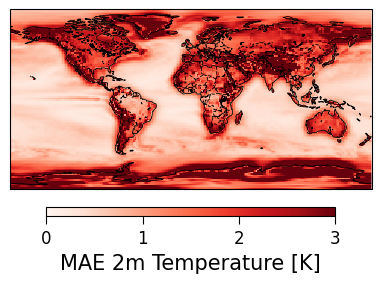

In [38]:
# MAE map for the smoothed baseline compared with ERA5
baseline_mae_map_path = plot_MAE_map(
    predictions=t2m_era5_smooth_version_plot,
    targets=t2m_era5_original_plot,
    lat_1d=test_target.latitude.values,
    lon_1d=test_target.longitude.values,
    variable_names=["T2M"],
    filename="baseline_t2m_mae_map.png",
    save_dir="./results",
)

display(Image(filename=baseline_mae_map_path))

#### Prediction MAE map

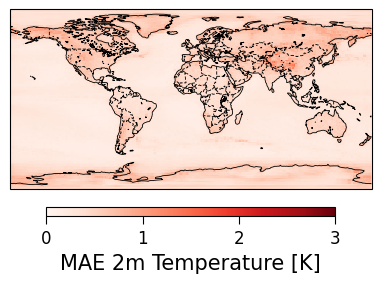

In [39]:
# MAE map for the Song U-Net prediction compared with ERA5
prediction_mae_map_path = plot_MAE_map(
    predictions=t2m_era5_prediction_plot,
    targets=t2m_era5_original_plot,
    lat_1d=test_target.latitude.values,
    lon_1d=test_target.longitude.values,
    variable_names=["T2M"],
    filename="prediction_t2m_mae_map.png",
    save_dir="./results",
)


display(Image(filename=prediction_mae_map_path))

#### **Interpretation**:

The MAE maps confirm the quantitative results. Compared with the smoothed baseline, the adapted Song U-Net prediction reduces the spatial reconstruction error over most regions.

The baseline MAE map shows larger errors, especially around regions with strong spatial gradients. In contrast, the prediction MAE map is much lighter overall, which means that the model output is closer to the ground truth `t2m_era5_original`.

However, some errors remain visible. They are mainly located over high-latitude regions, around complex topographic areas such as northern India and the Himalayas, and along some coastal regions, especially near the Pacific coast of South America and North America. One possible explanation is that these areas are more difficult to reconstruct because temperature can vary rapidly due to topography and land-sea contrast.

### 4.9 - Hexbin plot

#### **Hexbin plot for the Baseline**

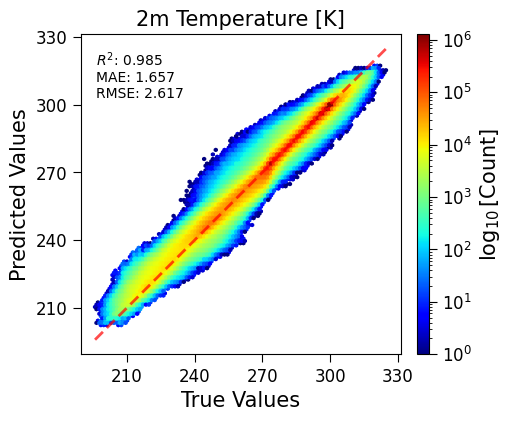

In [43]:
# Hexbin plot: smoothed baseline vs ERA5 truth
hexbin_baseline_path = plot_validation_hexbin(
    predictions=t2m_era5_smooth_version,
    targets=t2m_era5_original,
    variable_names=["T2M"],
    filename="baseline_t2m_validation_hexbin.png",
    save_dir="./results",
)

display(Image(filename=hexbin_baseline_path))

#### **Hexbin plot for the prediction**

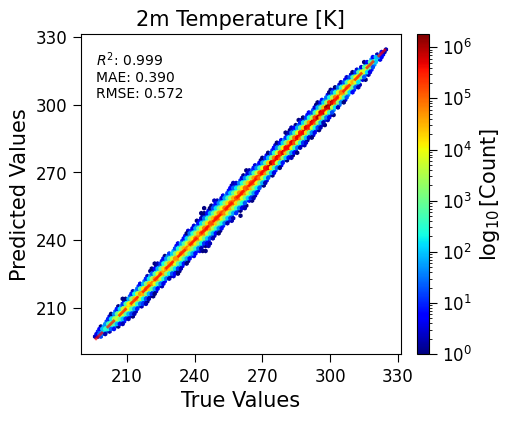

In [46]:
# Hexbin plot: prediction vs ERA5 truth
hexbin_baseline_path = plot_validation_hexbin(
    predictions=t2m_era5_prediction,
    targets=t2m_era5_original,
    variable_names=["T2M"],
    filename="baseline_t2m_validation_hexbin.png",
    save_dir="./results",
)

display(Image(filename=hexbin_baseline_path))

#### **Interpretation**:

The hexbin plots compare the predicted temperature values with the ERA5 truth over the full test set. The red dashed line represents the ideal case where the predicted value is exactly equal to the true value.

For the smoothed baseline, the points are more spread around the 1:1 line. This shows that the Gaussian-smoothed input loses part of the spatial variability and does not perfectly match the ERA5 truth. The baseline errors are higher, with a MAE of 1.657 K and an RMSE of 2.617 K.

In contrast, the Song U-Net prediction is much more concentrated around the 1:1 line. The model strongly reduces the dispersion and predicts values closer to the ERA5 target. This is confirmed by the lower MAE of 0.390 K and RMSE of 0.572 K.

Overall, the adapted Song U-Net corrects a large part of the errors introduced by the smoothing process and reconstructs temperature values that are much closer to the original ERA5 field than the smoothed baseline.

### 4.9 - Qualitative Surface Visualization

Finally, I visualize one test example using `plot_surface` from IPSL-AID diagnostics. This plot compares the smoothed input, the ERA5 truth, the model prediction and the prediction error.

Forecast for 2021-01-01 00:00


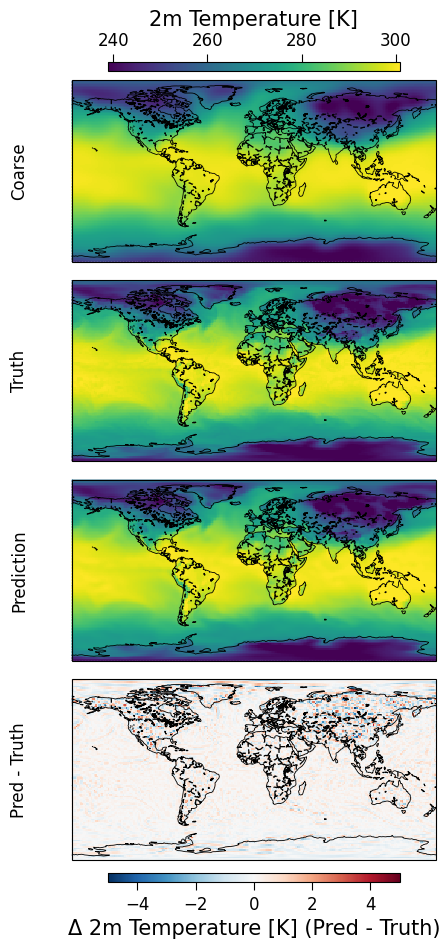

In [40]:
time_idx = 0

#Plot surface for visualization
surface_plot_path = plot_surface(
    predictions=t2m_era5_prediction_plot[time_idx:time_idx + 1],
    targets=t2m_era5_original_plot[time_idx:time_idx + 1],
    coarse_inputs=t2m_era5_smooth_version_plot[time_idx:time_idx + 1],
    lat_1d=test_target.latitude.values,
    lon_1d=test_target.longitude.values,
    timestamp=pd.to_datetime(str(test_target.time.values[time_idx])),
    variable_names=["T2M"],
    filename="songunet_t2m_surface_comparison.png",
    save_dir="./results",
)

display(Image(filename=surface_plot_path))

#### **Interpretation :**

The qualitative surface plot shows that the prediction is visually close to the ERA5 truth `t2m_era5_original`.

The error map `Prediction - Truth` confirms that the model prediction is generally close to the ERA5 reference. Some local errors remain, especially over high-latitude regions and complex continental areas. One possible explanation is that these regions may be harder to reconstruct because temperature can vary rapidly due to topography or land-sea contrast.

# 5 - Conclusion and Future Improvements


We addressed the inverse problem:

$$
t2m_{era5} = \mathbf{F}(t2m_{smooth})
$$

To solve this task, I trained a Song U-Net architecture imported from the IPSL-AID GitHub repository. The original architecture was adapted to a deterministic supervised setting, without diffusion preconditioning. I also reduced the model size in order to make training feasible on a free Google Colab GPU, and trained it for 10 epochs.

Despite this short training time and the reduced model capacity, the results show that the model successfully improves the reconstruction compared with the Gaussian-smoothed baseline. The prediction is closer to the original ERA5 field, as shown by the decrease in RMSE and MAE, the high $R^2$ score, the upper-tail quantile analysis, the PSD comparison, and the spatial MAE maps.

The model is therefore able to learn part of the missing information removed by the smoothing process and to reconstruct temperature fields closer to the ERA5 ground truth.

Several improvements could be explored. First, the model could be trained for more epochs and on a longer training period. Second, the model capacity could be increased by using more channels or more residual blocks, closer to the original IPSL-AID Song U-Net configuration. Third, a more complete hyperparameter tuning could be performed, including the learning rate, batch size, scheduler and weight decay.

Another possible improvement would be to modify the training objective. For example, adding a gradient loss could encourage the model to better reconstruct high-frequency spatial variability and sharper local structures. Training the model to predict the residual

$$
t2m_{era5} - t2m_{smooth}
$$

instead of directly predicting `t2m_era5` could also help the model focus more directly on the small-scale information removed by the Gaussian smoothing.

Finally, the current model is deterministic. This makes it simple and fast, but it does not provide uncertainty estimates. A diffusion-based model, as used in the IPSL-AID paper, would be more powerful for this purpose because it can generate several plausible high-resolution outputs for the same input. This would make it possible to quantify uncertainty and better represent the probabilistic nature of climate downscaling.

Some boundary artifacts were also observed near the left and right sides of the global map. A possible improvement would be to explicitly handle the periodic nature of longitude, for example with circular padding or overlap-based inference.

## Bibliographie

[1] Copernicus Climate Change Service (C3S), "ERA5 hourly data on single levels from 1940 to present," Copernicus Climate Data Store (CDS), 2023. [Online]. Available: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels. doi: 10.24381/cds.adbb2d47.

[2] K. Kingston et al., "IPSL-AID: Generative Diffusion Models for Climate Downscaling from Global to Regional Scales," arXiv preprint arXiv:2604.03275, 2026. [Online]. Available: https://arxiv.org/abs/2604.03275

[3] World Meteorological Organization, "Records of Weather and Climate Extremes Table," World Meteorological Organization (WMO), Jul. 31, 2025. [Online]. Available: https://wmo.int/resources/records-weather-and-climate-extremes-table.

[4] R. Fisher, S. Perkins, A. Walker, and E. Wolfart, "Spatial Filters - Gaussian Smoothing," Hypermedia Image Processing Reference (HIPR2), Univ. of Edinburgh, 2003. [Online]. Available: https://homepages.inf.ed.ac.uk/rbf/HIPR2/gsmooth.htm.

[5] F. Wang, D. Tian, L. Lowe, L. Kalin, and J. Lehrter, "Deep learning for daily precipitation and temperature downscaling," Water Resour. Res., vol. 57, no. 4, Apr. 2021, Art. no. e2020WR029308, doi: 10.1029/2020WR029308.

[6] Ge L and Dou L 2023 G-Loss: a loss function with gradient information for super-resolution Optik 280 170750